# 准备工作：
## 1：启动虚拟环境,安装Flink安装包

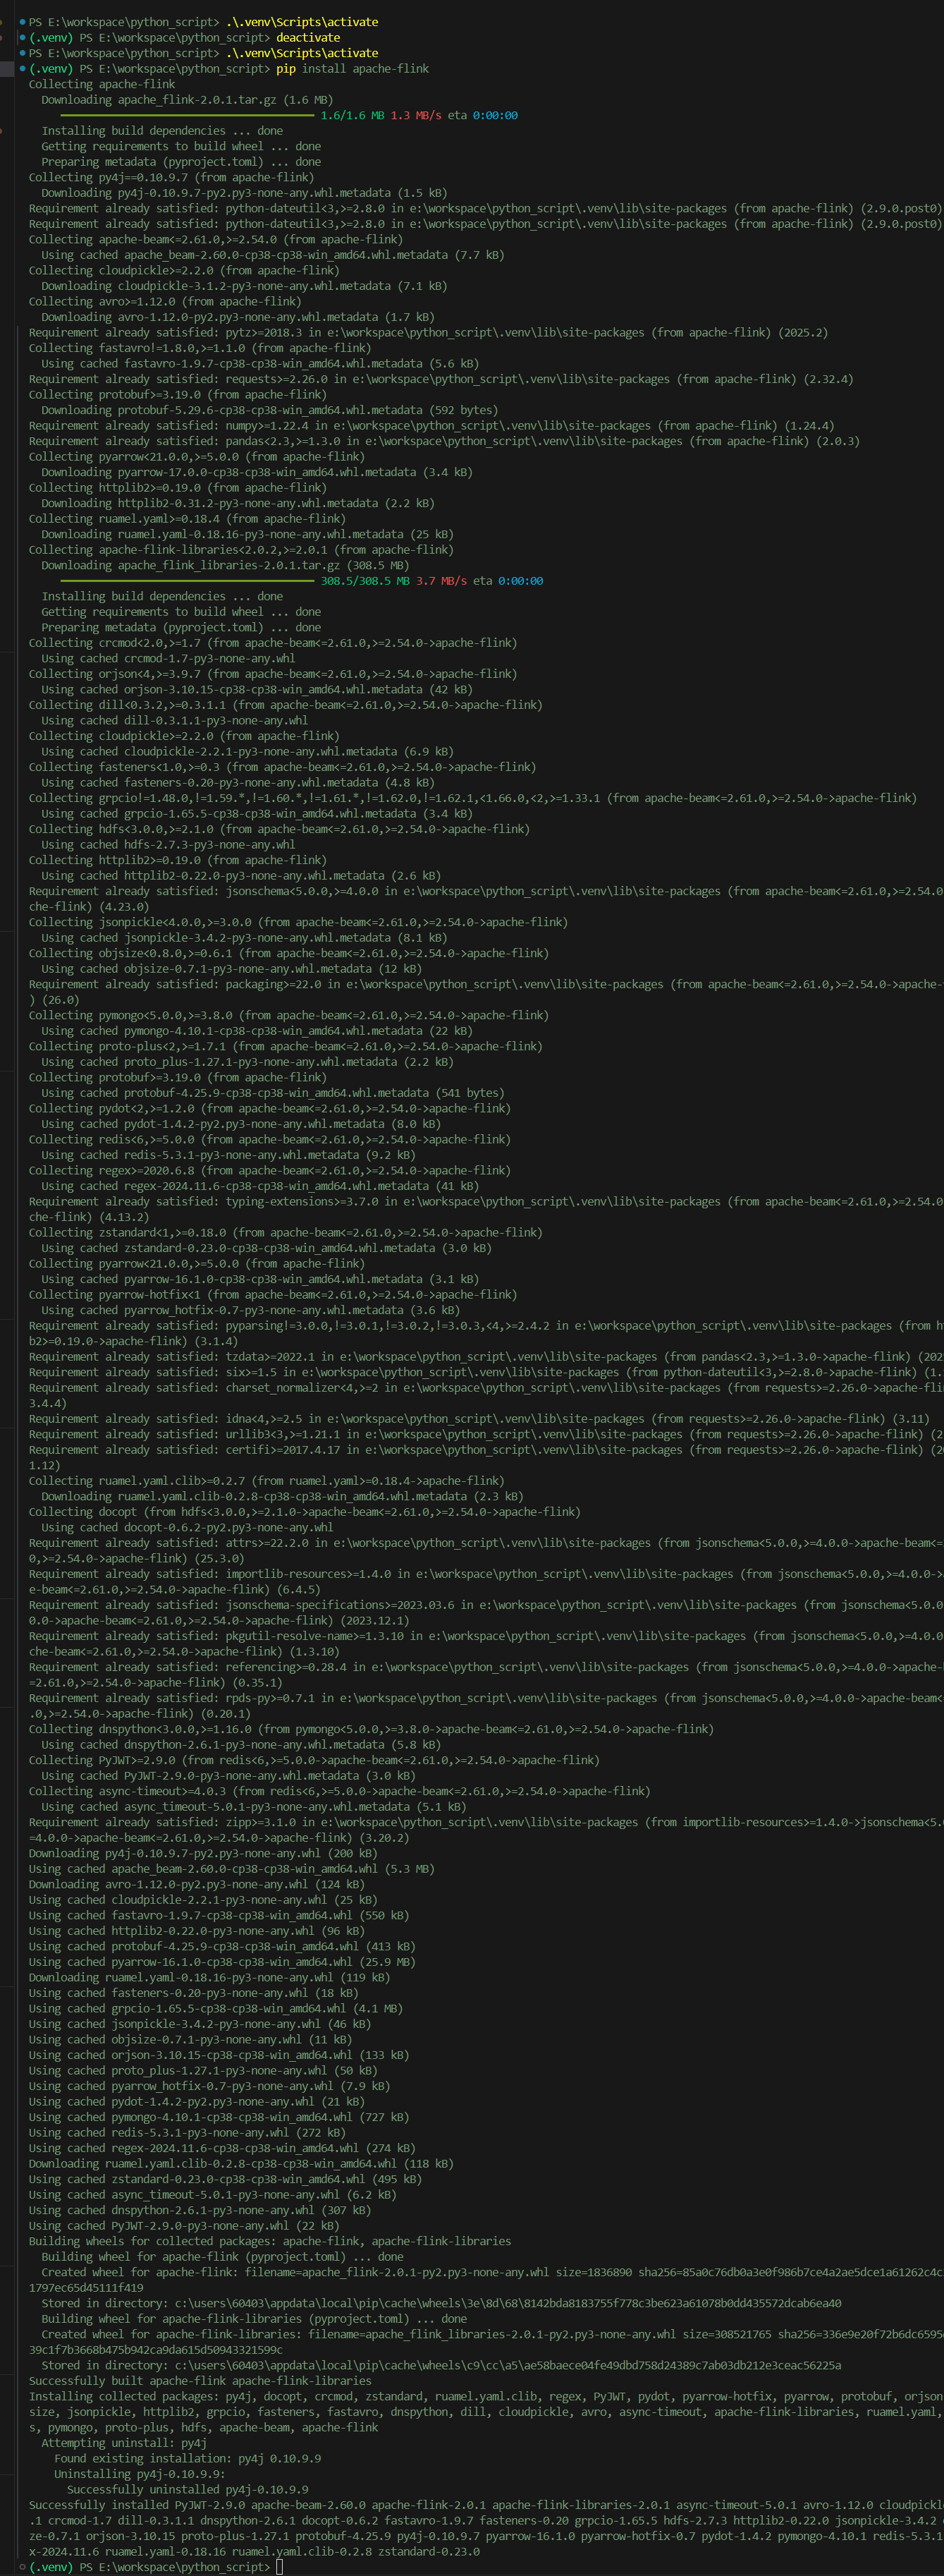
## 查看flink的版本号
from  pyflink import version
print(version.__version__)
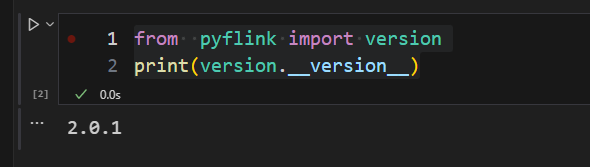
## 或者终端执行
pip show apache-flink
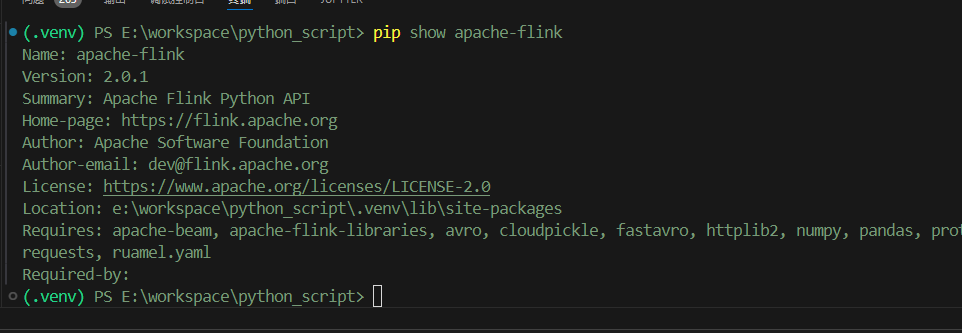

In [3]:
# 查看Flink的版本号
from  pyflink import version
print(version.__version__)

2.0.1


In [4]:
from pyflink.table import EnvironmentSettings,TableEnvironment
# 1. 创建表环境
# 指定执行模式为 BATCH 为in_batch_mode()
env_setting=EnvironmentSettings.in_batch_mode()
table_env=TableEnvironment.create(env_setting)
# 2. 创建源表 (例如从控制台读取)
table_env.execute_sql(''' 
       create table source_table(
               word STRING,
               cnt BIGINT
        )with(
             'connector'='datagen',
              'number-of-rows' = '15',
             'fields.word.length'='5',
             'fields.cnt.min'='1',
             'fields.cnt.max'='5'     
             )
    '''
)

e:\workspace\python_script\.venv\lib\site-packages\apache_beam\__init__.py:79: UserWarning: Python 3.8 reaches EOL in October 2024 and support will be removed from Apache Beam in version 2.61.0. See https://github.com/apache/beam/issues/31192 for more information.
  warnings.warn(


In [5]:
# 3. 创建结果表 (例如输出到控制台)
table_env.execute_sql(''' 
         create table sink_table(
                      word STRING,
                      cnt BIGINT
                      )with(
                      'connector'='print'
                      )
'''

)

In [6]:
# 4. 执行 SQL 逻辑
table_env.execute_sql(''' 
          insert into sink_table
                      select word,cnt
                      from source_table
                      where cnt>=1
'''
).wait()